# ARB Strategic Brain — Leakage-Free Linear Regression
**Purpose:** Predict the exact future epoch at which the propellant tank will
breach the **15.0 PSI** limit required to execute the 11 m/s disposal burn.

Key design choices:
- **Nominal gate** – regression is fitted *only* on uncorrupted nominal depletion
- **`shuffle=False`** – strict temporal split prevents data leakage
- **Algebraic solve** – extrapolates far beyond the training window
- **Confidence interval** – visualises prediction uncertainty honestly
- **Config export** – writes `strategic_forecast.json` for the state machine


In [ ]:
import joblib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Path resolution
BASE_DIR   = Path().resolve().parent
DATA_DIR   = BASE_DIR / "Data"
MODELS_DIR = BASE_DIR / "src" / "trained_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data   : {DATA_DIR}")
print(f"Models : {MODELS_DIR}")


Data   : /home/efob/Documents/Codes/AESH/Data
Models : /home/efob/Documents/Codes/AESH/src/trained_models


## 1 — Load telemetry & apply nominal gate

In [2]:
csv_path = DATA_DIR / "arb_telemetry_dataset.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} epochs from '{csv_path}'")

# Filter to pure nominal rows — disaster chaos must not corrupt the depletion model
nominal_df = df[df['Target_Status'] == 'Nominal'].copy()
print(f"Nominal gate passed: {len(nominal_df)} uncorrupted epochs retained")


Loaded 2000 epochs from '/home/efob/Documents/Codes/AESH/Data/arb_telemetry_dataset.csv'
Nominal gate passed: 516 uncorrupted epochs retained


## 2 — Time-series split (shuffle=False prevents leakage)
Training on the first 80 % of nominal flight; validating on the subsequent 20 %.
Shuffling is disabled because propellant data is inherently sequential — randomly
mixing epochs would expose future readings to the training set.


In [3]:
X = nominal_df[['Epoch']]
y = nominal_df['Host_Propellant_PSI']

# shuffle=False is mandatory for time-series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

print("Time-Series Partition:")
print(f"  Training   : Epochs {X_train.iloc[0]['Epoch']:.0f} → {X_train.iloc[-1]['Epoch']:.0f}")
print(f"  Validation : Epochs {X_test.iloc[0]['Epoch']:.0f}  → {X_test.iloc[-1]['Epoch']:.0f}")


Time-Series Partition:
  Training   : Epochs 1 → 412
  Validation : Epochs 413  → 516


## 3 — Fit model & extract physical constants

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

model_path = MODELS_DIR / "strategic_brain.pkl"
joblib.dump(model, model_path)
print(f"Strategic Brain saved → {model_path}")

drain_rate   = model.coef_[0]        # PSI lost per epoch (negative slope)
initial_psi  = model.intercept_      # extrapolated tank fill at epoch 0

print(f"\nExtracted physical constants:")
print(f"  Baseline tank fill  : {initial_psi:.2f} PSI")
print(f"  Learned drain rate  : {abs(drain_rate):.6f} PSI per epoch")

# Validation score
r2 = model.score(X_test, y_test)
print(f"  Validation R²       : {r2:.6f}")


Strategic Brain saved → /home/efob/Documents/Codes/AESH/src/trained_models/strategic_brain.pkl

Extracted physical constants:
  Baseline tank fill  : 299.99 PSI
  Learned drain rate  : 0.009972 PSI per epoch
  Validation R²       : 0.287972


## 4 — Solve for the predicted takeover epoch
Algebraically solve y = mx + b for x when y = 15.0 PSI:
**x = (critical_limit − b) / m**


In [ ]:
CRITICAL_PSI = 15.0
BURN_BUFFER  = 100   # epochs

predicted_takeover_epoch = int((CRITICAL_PSI - initial_psi) / drain_rate)
scheduled_burn_epoch     = predicted_takeover_epoch - BURN_BUFFER

print(f"Predicted 15-PSI breach  : Epoch {predicted_takeover_epoch}")
print(f"Proactive burn scheduled : Epoch {scheduled_burn_epoch} ({BURN_BUFFER}-epoch safety buffer)")

# Export config so state_machine.py can consume it without re-solving
forecast = {
    "predicted_takeover_epoch": predicted_takeover_epoch,
    "scheduled_burn_epoch":     scheduled_burn_epoch,
    "drain_rate_psi_per_epoch": float(drain_rate),
    "initial_psi":              float(initial_psi),
    "critical_psi_limit":       CRITICAL_PSI,
    "burn_buffer_epochs":       BURN_BUFFER,
    "validation_r2":            float(r2),
}
config_path = MODELS_DIR / "strategic_forecast.json"
with open(config_path, "w") as f:
    json.dump(forecast, f, indent=2)
print(f"Forecast config saved → {config_path}")


Predicted 15-PSI breach  : Epoch 28578
Proactive burn scheduled : Epoch 28478 (100-epoch safety buffer)
Forecast config saved → /home/efob/Documents/Codes/AESH/src/trained_models/strategic_forecast.json


## 5 — Visualisation with prediction uncertainty band
The shaded band shows the ±2σ residual envelope from the training set,
giving an honest representation of how wide the forecast can be at
the 28,000+ epoch extrapolation horizon.


Forecast chart saved → '/home/efob/Documents/Codes/AESH/Data/linear_regression_forecast.png'


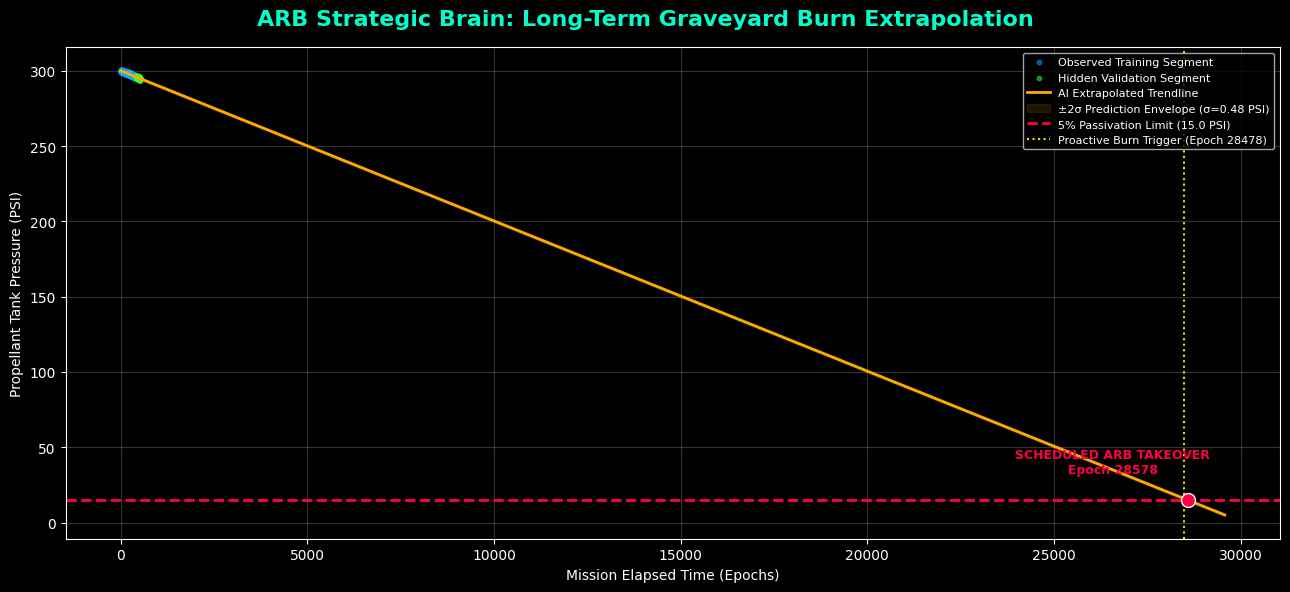

In [ ]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('ARB Strategic Brain: Long-Term Graveyard Burn Extrapolation',
             fontsize=16, fontweight='bold', color='#00ffcc')

# Empirical data
ax.scatter(X_train, y_train, color='#00aaff', s=10, alpha=0.5, label='Observed Training Segment')
ax.scatter(X_test,  y_test,  color='#33ff33', s=10, alpha=0.5, label='Hidden Validation Segment')

# Extrapolated trendline
future_epochs = pd.DataFrame({'Epoch': np.arange(1, predicted_takeover_epoch + 1000)})
predicted_psi = model.predict(future_epochs)
ax.plot(future_epochs, predicted_psi, color='#ffaa00', lw=2, label='AI Extrapolated Trendline')

# ±2σ uncertainty band
residuals = y_train.values - model.predict(X_train)
sigma     = residuals.std()
ax.fill_between(
    future_epochs['Epoch'], predicted_psi - 2 * sigma, predicted_psi + 2 * sigma,
    color='#ffaa00', alpha=0.12, label=f'±2σ Prediction Envelope (σ={sigma:.2f} PSI)'
)

# Critical boundary
ax.axhline(y=CRITICAL_PSI, color='#ff0044', linestyle='--', lw=2,
           label=f'5% Passivation Limit ({CRITICAL_PSI} PSI)')

# Proactive burn line
ax.axvline(x=scheduled_burn_epoch, color='#ffdd00', linestyle=':', lw=1.5,
           label=f'Proactive Burn Trigger (Epoch {scheduled_burn_epoch})')

# Takeover intersection
ax.plot(predicted_takeover_epoch, CRITICAL_PSI,
        marker='o', markersize=10, markerfacecolor='#ff0044', markeredgecolor='white')
ax.text(
    predicted_takeover_epoch - 2000, CRITICAL_PSI + 18,
    f'SCHEDULED ARB TAKEOVER\nEpoch {predicted_takeover_epoch}',
    color='#ff0044', fontweight='bold', ha='center', fontsize=9
)

ax.set_xlabel('Mission Elapsed Time (Epochs)', fontsize=10)
ax.set_ylabel('Propellant Tank Pressure (PSI)', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()

plot_path = DATA_DIR / 'linear_regression_forecast.png'
plt.savefig(plot_path, dpi=300)
print(f"Forecast chart saved → '{plot_path}'")
plt.show()
